In [1]:


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [4]:
def set_seed(seed=42):

    random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [5]:
DATASET_PATH = "/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset"
TRAIN_IMAGE_PATH = os.path.join(DATASET_PATH, "train", "images")

print(TRAIN_IMAGE_PATH)

/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/train/images


In [6]:
image_files = os.listdir(TRAIN_IMAGE_PATH)

print("Total Images:", len(image_files))
print(image_files[:5])

Total Images: 19186
['IMG_04498.jpg', 'IMG_16279.jpg', 'IMG_11219.jpg', 'IMG_00610.jpg', 'IMG_12470.jpg']


In [7]:
simclr_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        size=128,
        scale=(0.7, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.5,
        hue=0.1
    ),

    transforms.RandomGrayscale(p=0.2),

    transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
class SimCLRTransform:

    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, x):

        view1 = self.base_transform(x)
        view2 = self.base_transform(x)

        return view1, view2

In [9]:
class ObstacleDataset(Dataset):

    def __init__(self, image_dir, transform=None):

        self.image_dir = image_dir
        self.transform = transform

        valid_extensions = (".jpg", ".jpeg", ".png")

        self.image_paths = [
            os.path.join(image_dir, img)
            for img in os.listdir(image_dir)
            if img.lower().endswith(valid_extensions)
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [10]:
dataset = ObstacleDataset(
    image_dir=TRAIN_IMAGE_PATH,
    transform=SimCLRTransform(simclr_transform)
)

print("Dataset Size:", len(dataset))

Dataset Size: 19186


In [11]:
view1, view2 = dataset[0]

print("View1 Shape:", view1.shape)
print("View2 Shape:", view2.shape)

View1 Shape: torch.Size([3, 128, 128])
View2 Shape: torch.Size([3, 128, 128])


In [12]:
def denormalize(img_tensor):

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    img_tensor = img_tensor * std + mean

    return img_tensor.clamp(0, 1)

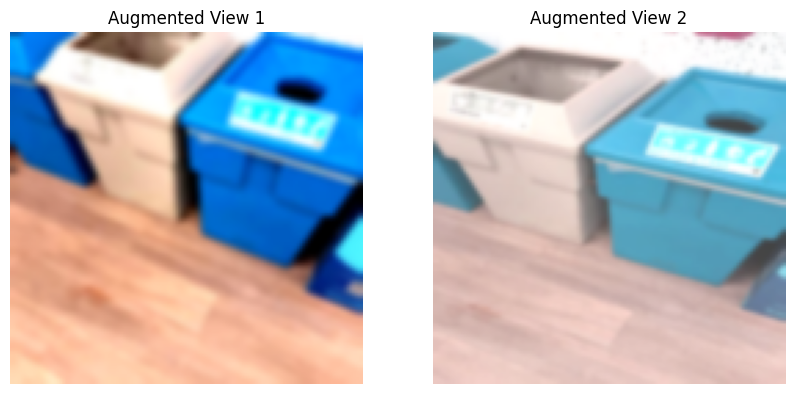

In [13]:
sample1, sample2 = dataset[random.randint(0, len(dataset)-1)]

sample1 = denormalize(sample1)
sample2 = denormalize(sample2)

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(sample1.permute(1,2,0))
ax[0].set_title("Augmented View 1")
ax[0].axis("off")

ax[1].imshow(sample2.permute(1,2,0))
ax[1].set_title("Augmented View 2")
ax[1].axis("off")

plt.show()

In [14]:
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

In [15]:
view1_batch, view2_batch = next(iter(train_loader))

print("View1 Batch Shape:", view1_batch.shape)
print("View2 Batch Shape:", view2_batch.shape)

View1 Batch Shape: torch.Size([64, 3, 128, 128])
View2 Batch Shape: torch.Size([64, 3, 128, 128])


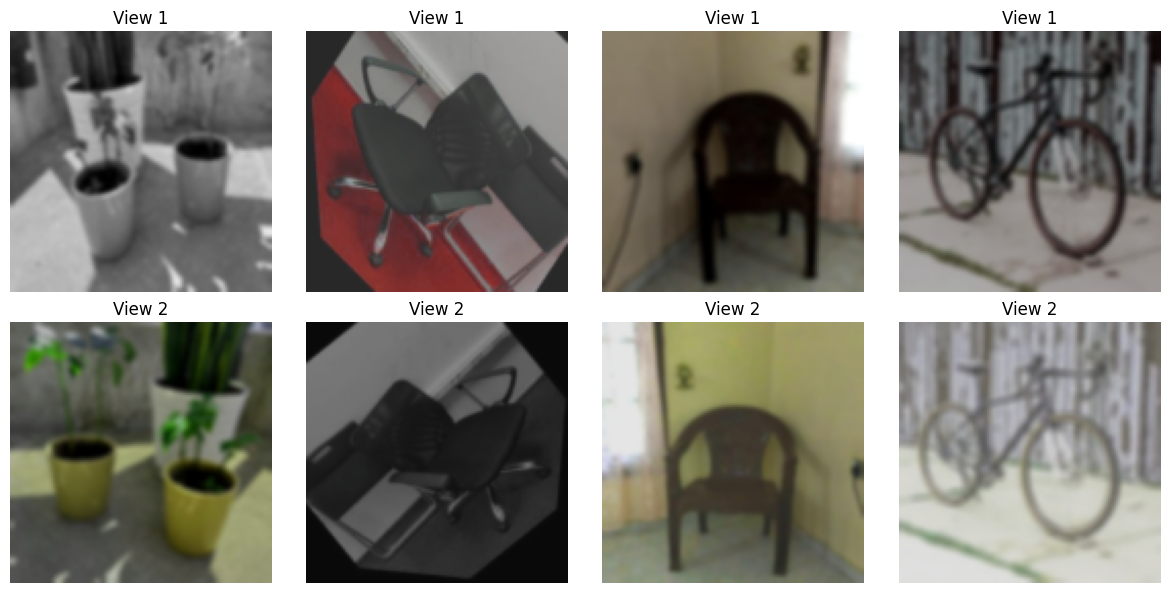

In [16]:
fig, ax = plt.subplots(2, 4, figsize=(12,6))

for i in range(4):

    img1 = denormalize(view1_batch[i]).permute(1,2,0)
    img2 = denormalize(view2_batch[i]).permute(1,2,0)

    ax[0, i].imshow(img1)
    ax[0, i].set_title("View 1")
    ax[0, i].axis("off")

    ax[1, i].imshow(img2)
    ax[1, i].set_title("View 2")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()

In [17]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models

In [18]:
class ResNetSimCLR(nn.Module):

    def __init__(self, projection_dim=128):

        super().__init__()

        # Load ResNet18
        self.encoder = models.resnet18(weights=None)

        # Remove classification layer
        num_features = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        # Projection Head
        self.projector = nn.Sequential(

            nn.Linear(num_features, 512),
            nn.ReLU(),

            nn.Linear(512, projection_dim)
        )

    def forward(self, x):

        h = self.encoder(x)

        z = self.projector(h)

        return h, z

In [19]:
model = ResNetSimCLR(
    projection_dim=128
).to(device)

print(model)

ResNetSimCLR(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [20]:
class NTXentLoss(nn.Module):

    def __init__(self, temperature=0.5):

        super().__init__()

        self.temperature = temperature

    def forward(self, z_i, z_j):

        batch_size = z_i.size(0)

        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)

        representations = torch.cat([z_i, z_j], dim=0)

        similarity_matrix = F.cosine_similarity(
            representations.unsqueeze(1),
            representations.unsqueeze(0),
            dim=2
        )

        # Remove self similarity
        mask = torch.eye(2 * batch_size, dtype=torch.bool).to(device)

        similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

        # Positive pairs
        positives = torch.cat([
            torch.diag(similarity_matrix, batch_size),
            torch.diag(similarity_matrix, -batch_size)
        ], dim=0)

        # Denominator
        logits = similarity_matrix / self.temperature

        exp_logits = torch.exp(logits)

        denominator = exp_logits.sum(dim=1)

        positives_exp = torch.exp(positives / self.temperature)

        loss = -torch.log(positives_exp / denominator)

        return loss.mean()

In [21]:
criterion = NTXentLoss(
    temperature=0.5
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [22]:
def train_simclr(model, loader, optimizer, criterion, epochs):

    

    loss_history = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0

        for view1, view2 in loader:

            view1 = view1.to(device)
            view2 = view2.to(device)

            _, z1 = model(view1)
            _, z2 = model(view2)

            loss = criterion(z1, z2)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        loss_history.append(avg_loss)

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:

            torch.save(
                model.state_dict(),
                f"simclr_epoch_{epoch+1}.pth"
            )

            print(f"Checkpoint Saved at Epoch {epoch+1}")

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f}")

    return loss_history

In [23]:
EPOCHS = 10

loss_history = train_simclr(
    model=model,
    loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS
)

# Save full SimCLR model
torch.save(
    model.state_dict(),
    "simclr_resnet18.pth"
)

# Save encoder only
torch.save(
    model.encoder.state_dict(),
    "simclr_encoder.pth"
)

print("Model and Encoder Saved")

Epoch [1/10] Loss: 3.7483
Epoch [2/10] Loss: 3.3353
Epoch [3/10] Loss: 3.2361
Epoch [4/10] Loss: 3.1866
Epoch [5/10] Loss: 3.1600
Epoch [6/10] Loss: 3.1351
Epoch [7/10] Loss: 3.1131
Epoch [8/10] Loss: 3.0999
Epoch [9/10] Loss: 3.0870
Checkpoint Saved at Epoch 10
Epoch [10/10] Loss: 3.0754
Model and Encoder Saved


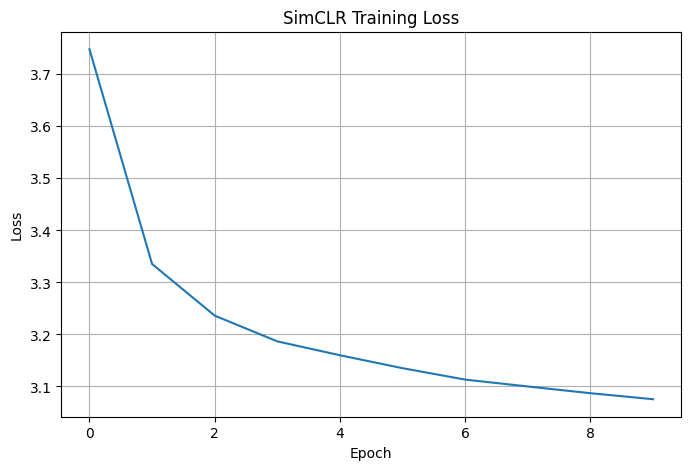

In [24]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.title("SimCLR Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

# Masked AutoEncoder

In [25]:
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [26]:
import timm

model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False
)

print("timm working")

timm working


In [27]:
import timm

import torch.nn as nn
import torch.optim as optim

In [28]:
mae_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [29]:
mae_dataset = ObstacleDataset(
    image_dir=TRAIN_IMAGE_PATH,
    transform=mae_transform
)

print("MAE Dataset Size:", len(mae_dataset))

MAE Dataset Size: 19186


In [30]:
mae_loader = DataLoader(
    mae_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

In [31]:
images = next(iter(mae_loader))

print(images.shape)

torch.Size([64, 3, 224, 224])


In [32]:
def random_mask(images, mask_ratio=0.75):

    batch_size, channels, height, width = images.shape

    patch_size = 16

    num_patches_h = height // patch_size
    num_patches_w = width // patch_size

    total_patches = num_patches_h * num_patches_w

    num_masked = int(mask_ratio * total_patches)

    masked_images = images.clone()

    for img in masked_images:

        mask_indices = random.sample(
            range(total_patches),
            num_masked
        )

        for idx in mask_indices:

            row = idx // num_patches_w
            col = idx % num_patches_w

            h_start = row * patch_size
            w_start = col * patch_size

            img[
                :,
                h_start:h_start+patch_size,
                w_start:w_start+patch_size
            ] = 0

    return masked_images

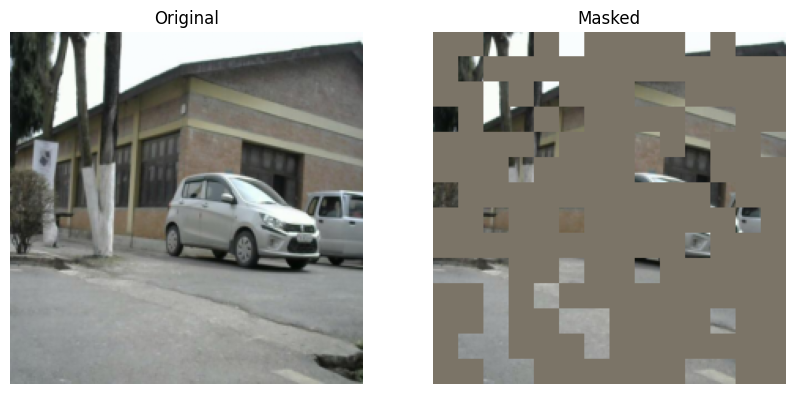

In [33]:
sample_batch = next(iter(mae_loader))

masked_batch = random_mask(sample_batch)

original = denormalize(sample_batch[0]).permute(1,2,0)
masked = denormalize(masked_batch[0]).permute(1,2,0)

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(original)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(masked)
ax[1].set_title("Masked")
ax[1].axis("off")

plt.show()

In [34]:
class SimpleMAE(nn.Module):

    def __init__(self):

        super().__init__()

        # ViT encoder
        self.encoder = timm.create_model(
            "vit_tiny_patch16_224",
            pretrained=False,
            num_classes=0
        )

        encoder_dim = self.encoder.num_features

        # Decoder
        self.decoder = nn.Sequential(

            nn.Linear(encoder_dim, 1024),
            nn.ReLU(),

            nn.Linear(1024, 3 * 224 * 224)
        )

    def forward(self, x):

        latent = self.encoder(x)

        reconstruction = self.decoder(latent)

        reconstruction = reconstruction.view(
            -1,
            3,
            224,
            224
        )

        return latent, reconstruction

In [35]:
mae_model = SimpleMAE().to(device)

print(mae_model)

SimpleMAE(
  (encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=192, out_features=576, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=192, out_features=192, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=192, out_features=768, bias=True)
          (act)

In [36]:
mae_criterion = nn.MSELoss()

mae_optimizer = optim.Adam(
    mae_model.parameters(),
    lr=1e-4
)

In [37]:
def train_mae(model, loader, optimizer, criterion, epochs):

    loss_history = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for batch_idx, images in enumerate(loader):

            images = images.to(device)

            masked_images = random_mask(
                images,
                mask_ratio=0.75
            ).to(device)

            latent, reconstructed = model(masked_images)

            loss = criterion(reconstructed, images)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            if batch_idx % 50 == 0:

                print(
                    f"Epoch [{epoch+1}/{epochs}] "
                    f"Batch [{batch_idx}/{len(loader)}] "
                    f"Loss: {loss.item():.4f}"
                )

        avg_loss = total_loss / len(loader)

        loss_history.append(avg_loss)

        print(f"\nEpoch [{epoch+1}/{epochs}] Average Loss: {avg_loss:.4f}\n")

    return loss_history

In [38]:
MAE_EPOCHS = 10

mae_loss_history = train_mae(
    model=mae_model,
    loader=mae_loader,
    optimizer=mae_optimizer,
    criterion=mae_criterion,
    epochs=MAE_EPOCHS
)

Epoch [1/10] Batch [0/299] Loss: 1.6152
Epoch [1/10] Batch [50/299] Loss: 0.9484
Epoch [1/10] Batch [100/299] Loss: 1.1468
Epoch [1/10] Batch [150/299] Loss: 1.0560
Epoch [1/10] Batch [200/299] Loss: 0.9372
Epoch [1/10] Batch [250/299] Loss: 0.9378

Epoch [1/10] Average Loss: 1.0620

Epoch [2/10] Batch [0/299] Loss: 0.9913
Epoch [2/10] Batch [50/299] Loss: 0.9898
Epoch [2/10] Batch [100/299] Loss: 0.9718
Epoch [2/10] Batch [150/299] Loss: 1.0226
Epoch [2/10] Batch [200/299] Loss: 0.9580
Epoch [2/10] Batch [250/299] Loss: 0.9825

Epoch [2/10] Average Loss: 0.9573

Epoch [3/10] Batch [0/299] Loss: 0.9346
Epoch [3/10] Batch [50/299] Loss: 1.1114
Epoch [3/10] Batch [100/299] Loss: 0.8900
Epoch [3/10] Batch [150/299] Loss: 1.0840
Epoch [3/10] Batch [200/299] Loss: 0.8576
Epoch [3/10] Batch [250/299] Loss: 0.9215

Epoch [3/10] Average Loss: 0.9222

Epoch [4/10] Batch [0/299] Loss: 0.8427
Epoch [4/10] Batch [50/299] Loss: 0.8352
Epoch [4/10] Batch [100/299] Loss: 0.8657
Epoch [4/10] Batch [15

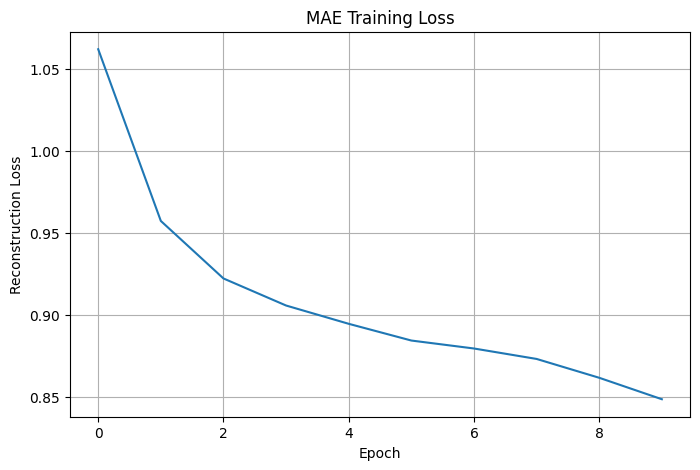

In [39]:
plt.figure(figsize=(8,5))

plt.plot(mae_loss_history)

plt.title("MAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")

plt.grid(True)

plt.show()

In [40]:
torch.save(
    mae_model.state_dict(),
    "simple_mae.pth"
)

torch.save(
    mae_model.encoder.state_dict(),
    "mae_encoder.pth"
)

print("MAE Model and Encoder Saved")

MAE Model and Encoder Saved


# Analysis

In [41]:
simclr_model = model

In [42]:
analysis_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [43]:
class AnalysisDataset(Dataset):

    def __init__(self, image_dir, transform=None):

        self.transform = transform

        valid_extensions = (".jpg", ".jpeg", ".png")

        self.image_paths = [
            os.path.join(image_dir, img)
            for img in os.listdir(image_dir)
            if img.lower().endswith(valid_extensions)
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path

In [44]:
analysis_dataset = AnalysisDataset(
    TRAIN_IMAGE_PATH,
    transform=analysis_transform
)

analysis_loader = DataLoader(
    analysis_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4
)

In [45]:
simclr_model = ResNetSimCLR(
    projection_dim=128
).to(device)

simclr_model.load_state_dict(
    torch.load("simclr_resnet18.pth")
)

simclr_model.eval()

print("SimCLR model loaded")

SimCLR model loaded


In [46]:
simclr_embeddings = []
simclr_paths = []

simclr_model = simclr_model.to(device)

simclr_model.eval()

with torch.no_grad():

    for images, paths in analysis_loader:

        images = images.to(device)

        h, z = simclr_model(images)

        simclr_embeddings.append(h.cpu())

        simclr_paths.extend(paths)

In [47]:
simclr_embeddings = torch.cat(
    simclr_embeddings,
    dim=0
)

print(simclr_embeddings.shape)

torch.Size([19186, 512])


In [48]:
mae_model = SimpleMAE().to(device)

mae_model.load_state_dict(
    torch.load("simple_mae.pth")
)

mae_model.eval()

print("MAE model loaded")

MAE model loaded


In [49]:
mae_embeddings = []

with torch.no_grad():

    for images, _ in analysis_loader:

        images = images.to(device)

        latent, reconstruction = mae_model(images)

        mae_embeddings.append(latent.cpu())

In [50]:
mae_embeddings = torch.cat(
    mae_embeddings,
    dim=0
)

print(mae_embeddings.shape)

torch.Size([19186, 192])


In [51]:
torch.save(
    simclr_embeddings,
    "simclr_embeddings.pt"
)

print("SimCLR embeddings saved")

torch.save(
    mae_embeddings,
    "mae_embeddings.pt"
)

print("MAE embeddings saved")



SimCLR embeddings saved
MAE embeddings saved
